# Анализ метрик моделей из папки `results`

В этом ноутбуке я собираю результаты всех моделей из папки `results`, считаю основные метрики и делаю несколько простых визуализаций.

Идея такая:

- прочитать все `.json` файлы с результатами,
- аккуратно вытащить название модели,
- посчитать агрегированные метрики,
- собрать всё в одну таблицу,
- визуально сравнить модели между собой.

Ноутбук разбит на небольшие ячейки, чтобы его было удобно читать и дорабатывать.

## 1. Импорты

Сначала подключаем нужные библиотеки.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 2. Путь к папке с результатами

Предполагается, что в Colab уже доступна папка `results`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
RESULTS_DIR = Path("/content/drive/MyDrive/llm-benchmark/results")
RESULTS_DIR

PosixPath('/content/drive/MyDrive/llm-benchmark/results')

## 3. Вспомогательные функции

Здесь лежат маленькие утилиты:

- безопасное среднее,
- загрузка одного json-файла,
- определение имени модели по содержимому файла или по имени файла.

In [4]:
def safe_mean(values):
    values = [v for v in values if v is not None]
    return sum(values) / len(values) if values else 0.0


def load_results(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def infer_model_name(data: list[dict], path: Path) -> str:
    # Если в самом файле явно указано поле model, берем его.
    if data and isinstance(data[0], dict) and "model" in data[0] and data[0]["model"]:
        return str(data[0]["model"])

    stem = path.stem.lower()

    # results_llama -> llama
    if stem.startswith("results_"):
        return path.stem[len("results_"):]

    # llama_results -> llama
    if stem.endswith("_results"):
        return path.stem[:-len("_results")]

    # Во всех остальных случаях оставляем имя файла как есть.
    return path.stem

## 4. Функция подсчета метрик для одной модели

Здесь из списка ответов собираются агрегированные показатели:

- доля корректных ответов,
- доля галлюцинаций,
- доля mixed и unclear,
- средние judge-оценки,
- средняя задержка ответа.

In [5]:
def compute_metrics(data: list[dict]) -> dict:
    judges = [
        x["judge"] for x in data
        if isinstance(x, dict) and isinstance(x.get("judge"), dict)
    ]

    judge_count = len(judges)

    truthfulness_rate = (
        sum(j.get("truth_verdict") == "correct" for j in judges) / judge_count
        if judge_count else 0.0
    )
    hallucination_rate = (
        sum(bool(j.get("contains_incorrect_claim")) for j in judges) / judge_count
        if judge_count else 0.0
    )
    mixed_rate = (
        sum(j.get("truth_verdict") == "mixed" for j in judges) / judge_count
        if judge_count else 0.0
    )
    unclear_rate = (
        sum(j.get("truth_verdict") == "unclear" for j in judges) / judge_count
        if judge_count else 0.0
    )

    mean_truth_score = safe_mean([j.get("truth_score") for j in judges])
    mean_best_answer_score = safe_mean([j.get("best_answer_score") for j in judges])
    mean_overall_score = safe_mean([j.get("overall_score") for j in judges])
    mean_latency = safe_mean([x.get("latency") for x in data if isinstance(x, dict)])

    return {
        "samples": len(data),
        "judged_samples": judge_count,
        "truthfulness_rate": round(truthfulness_rate, 4),
        "hallucination_rate": round(hallucination_rate, 4),
        "mixed_rate": round(mixed_rate, 4),
        "unclear_rate": round(unclear_rate, 4),
        "mean_truth_score": round(mean_truth_score, 4),
        "mean_best_answer_score": round(mean_best_answer_score, 4),
        "mean_overall_score": round(mean_overall_score, 4),
        "mean_latency": round(mean_latency, 4),
    }

## 5. Сбор метрик по всем json-файлам

Эта функция проходит по всем файлам из папки `results`, считает метрики и собирает их в один `DataFrame`.

In [6]:
def load_all_metrics(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    result_files = sorted(results_dir.glob("*.json"))

    if not result_files:
        raise FileNotFoundError("Нет json-файлов в папке results/")

    rows = []

    for path in result_files:
        try:
            data = load_results(path)

            if not isinstance(data, list):
                print(f"[SKIP] {path.name}: файл не является list[dict]")
                continue

            model_name = infer_model_name(data, path)
            metrics = compute_metrics(data)

            row = {
                "model": model_name,
                "file": path.name,
                **metrics,
            }
            rows.append(row)

        except Exception as e:
            print(f"[ERROR] {path.name}: {e}")

    if not rows:
        raise ValueError("Не удалось загрузить ни одного корректного файла с результатами.")

    df = pd.DataFrame(rows)

    # Основная сортировка: сначала по overall score, потом по truthfulness.
    df = df.sort_values(
        by=["mean_overall_score", "truthfulness_rate", "mean_truth_score"],
        ascending=False
    ).reset_index(drop=True)

    return df

## 6. Загружаем итоговую таблицу

На этом шаге уже можно посмотреть сводную таблицу по всем моделям.

In [7]:
df = load_all_metrics()
df

,model,file,samples,judged_samples,truthfulness_rate,hallucination_rate,mixed_rate,unclear_rate,mean_truth_score,mean_best_answer_score,mean_overall_score,mean_latency
0,openai/gpt-oss-20b,gpt_20B_results.json,200,200,0.740,0.2150,0.1200,0.0300,0.8000,2.9400,0.7144,0.6394
1,llama-3.3-70b-versatile,llama_results.json,200,200,0.735,0.2500,0.1400,0.0050,0.8050,2.8800,0.6950,0.4721
2,qwen/qwen3-32b,qwen_results.json,200,200,0.710,0.2850,0.1950,0.0050,0.8075,2.8600,0.6844,1.9882
3,meta-llama/llama-4-scout-17b-16e-instruct,llama_17B_results.json,63,63,0.619,0.3651,0.2698,0.0159,0.7540,2.7778,0.6369,0.4380
4,llama-3.1-8b-instant,llama_8B_results.json,200,200,0.410,0.5600,0.2450,0.0250,0.5325,1.8250,0.4119,0.3576


## 7. Чуть более красивое отображение таблицы

Зеленым подсвечиваем хорошие значения, для скорости и уровня галлюцинаций логика обратная.

In [8]:
display(
    df.style
      .background_gradient(
          subset=["truthfulness_rate", "mean_truth_score", "mean_best_answer_score", "mean_overall_score"],
          cmap="Greens"
      )
      .background_gradient(
          subset=["hallucination_rate", "mean_latency"],
          cmap="Reds_r"
      )
      .format({
          "truthfulness_rate": "{:.2%}",
          "hallucination_rate": "{:.2%}",
          "mixed_rate": "{:.2%}",
          "unclear_rate": "{:.2%}",
          "mean_truth_score": "{:.3f}",
          "mean_best_answer_score": "{:.3f}",
          "mean_overall_score": "{:.3f}",
          "mean_latency": "{:.3f}",
      })
)

,model,file,samples,judged_samples,truthfulness_rate,hallucination_rate,mixed_rate,unclear_rate,mean_truth_score,mean_best_answer_score,mean_overall_score,mean_latency
0,openai/gpt-oss-20b,gpt_20B_results.json,200,200,74.00%,21.50%,12.00%,3.00%,0.800,2.940,0.714,0.639
1,llama-3.3-70b-versatile,llama_results.json,200,200,73.50%,25.00%,14.00%,0.50%,0.805,2.880,0.695,0.472
2,qwen/qwen3-32b,qwen_results.json,200,200,71.00%,28.50%,19.50%,0.50%,0.807,2.860,0.684,1.988
3,meta-llama/llama-4-scout-17b-16e-instruct,llama_17B_results.json,63,63,61.90%,36.51%,26.98%,1.59%,0.754,2.778,0.637,0.438
4,llama-3.1-8b-instant,llama_8B_results.json,200,200,41.00%,56.00%,24.50%,2.50%,0.532,1.825,0.412,0.358


## 8. Отдельная таблица для рейтинга моделей

Иногда удобно оставить только самые важные столбцы.

In [9]:
ranking_cols = [
    "model",
    "samples",
    "judged_samples",
    "truthfulness_rate",
    "hallucination_rate",
    "mean_truth_score",
    "mean_best_answer_score",
    "mean_overall_score",
    "mean_latency",
]

ranking = df[ranking_cols].copy()
ranking

,model,samples,judged_samples,truthfulness_rate,hallucination_rate,mean_truth_score,mean_best_answer_score,mean_overall_score,mean_latency
0,openai/gpt-oss-20b,200,200,0.740,0.2150,0.8000,2.9400,0.7144,0.6394
1,llama-3.3-70b-versatile,200,200,0.735,0.2500,0.8050,2.8800,0.6950,0.4721
2,qwen/qwen3-32b,200,200,0.710,0.2850,0.8075,2.8600,0.6844,1.9882
3,meta-llama/llama-4-scout-17b-16e-instruct,63,63,0.619,0.3651,0.7540,2.7778,0.6369,0.4380
4,llama-3.1-8b-instant,200,200,0.410,0.5600,0.5325,1.8250,0.4119,0.3576


## 9. Визуализация: средний `overall score` по моделям

Это самый прямой способ быстро посмотреть, кто лидирует по общей оценке.

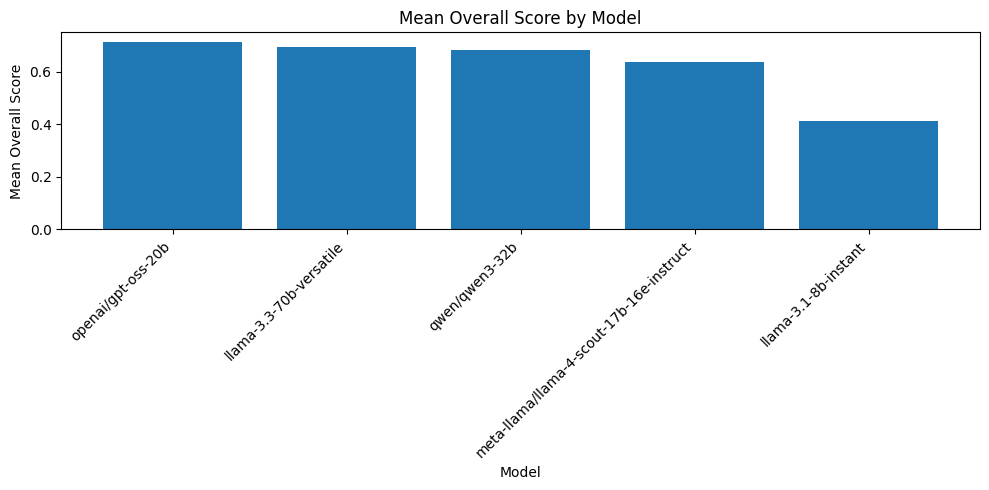

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(df["model"], df["mean_overall_score"])
plt.title("Mean Overall Score by Model")
plt.xlabel("Model")
plt.ylabel("Mean Overall Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Визуализация: правдивость против галлюцинаций

Хорошие модели обычно находятся правее и ниже:

- правее — выше `truthfulness_rate`,
- ниже — меньше `hallucination_rate`.

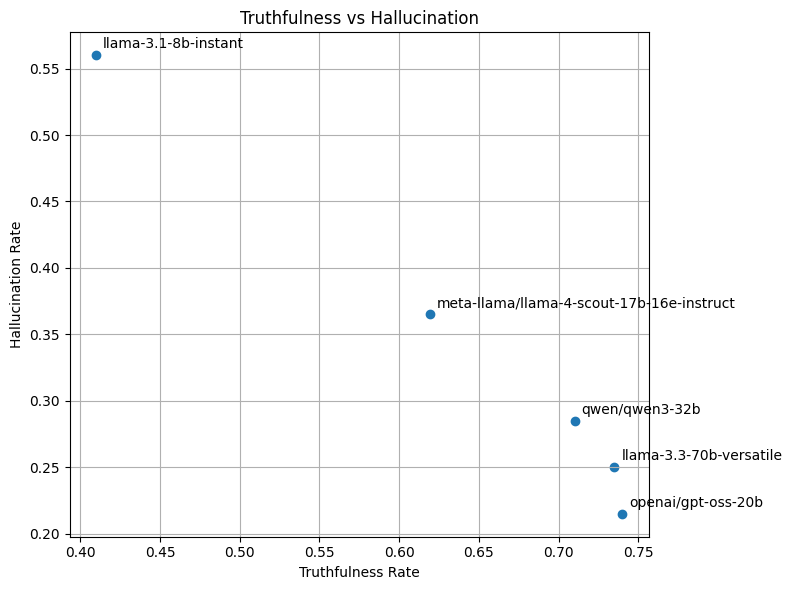

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df["truthfulness_rate"], df["hallucination_rate"])

for _, row in df.iterrows():
    plt.annotate(
        row["model"],
        (row["truthfulness_rate"], row["hallucination_rate"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Truthfulness vs Hallucination")
plt.xlabel("Truthfulness Rate")
plt.ylabel("Hallucination Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Визуализация: средняя задержка ответа

Эта диаграмма нужна, если хочется сравнить не только качество, но и скорость.

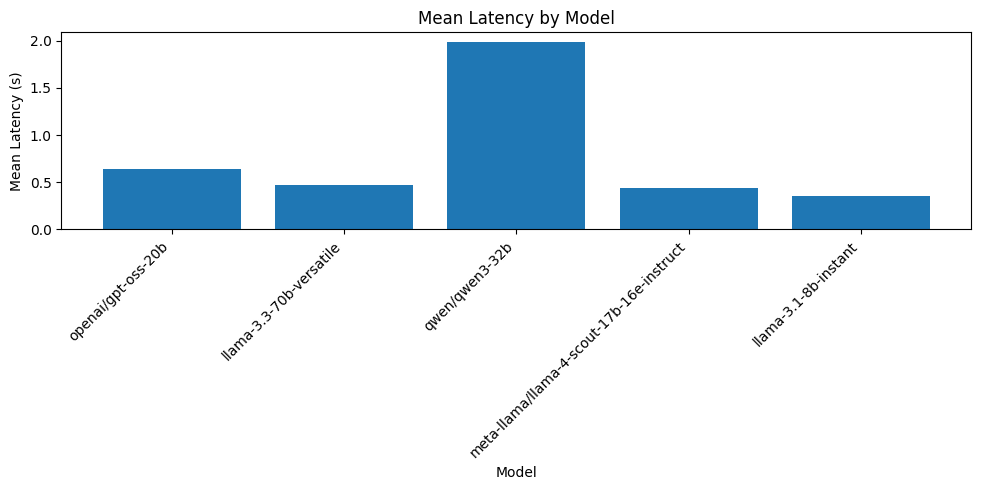

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(df["model"], df["mean_latency"])
plt.title("Mean Latency by Model")
plt.xlabel("Model")
plt.ylabel("Mean Latency (s)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Сравнение нескольких метрик на одном графике

Так удобнее смотреть на баланс между качеством и ошибками.

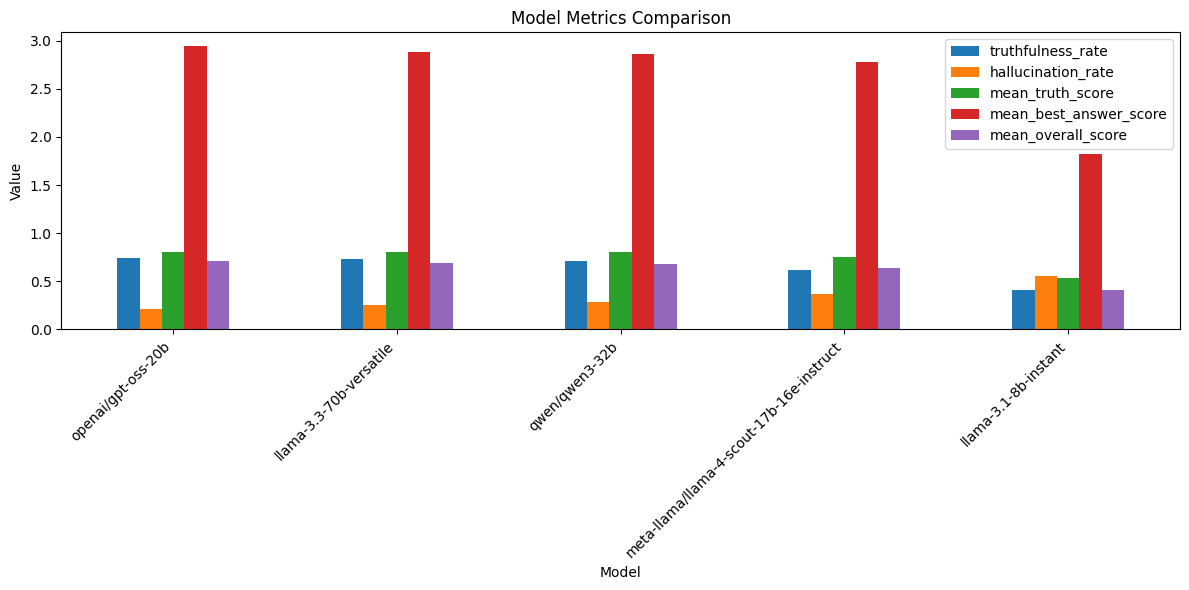

In [13]:
plot_cols = [
    "truthfulness_rate",
    "hallucination_rate",
    "mean_truth_score",
    "mean_best_answer_score",
    "mean_overall_score",
]

plot_df = df[["model"] + plot_cols].set_index("model")
plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Metrics Comparison")
plt.xlabel("Model")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Короткая итоговая сводка

Здесь просто автоматически выбирается лучшая модель по разным критериям.

In [14]:
summary = {
    "best_overall_score": df.loc[df["mean_overall_score"].idxmax(), "model"],
    "best_truthfulness_rate": df.loc[df["truthfulness_rate"].idxmax(), "model"],
    "lowest_hallucination_rate": df.loc[df["hallucination_rate"].idxmin(), "model"],
    "fastest_model": df.loc[df["mean_latency"].idxmin(), "model"],
}

summary

{'best_overall_score': 'openai/gpt-oss-20b',
 'best_truthfulness_rate': 'openai/gpt-oss-20b',
 'lowest_hallucination_rate': 'openai/gpt-oss-20b',
 'fastest_model': 'llama-3.1-8b-instant'}

## 14. Сохранение таблицы в CSV

Полезно, если потом захочется приложить результаты к отчету или открыть в Excel.

In [15]:
df.to_csv("model_metrics_summary.csv", index=False, encoding="utf-8")
print("Сохранено в model_metrics_summary.csv")

Сохранено в model_metrics_summary.csv


Все выводы из проделанной работы оформил в README